In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('ford.csv')
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
print(df.shape)
print(df.info())
print(df.describe(),'describeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee')

(17966, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB
None
               year         price        mileage           tax           mpg  \
count  17966.000000  17966.000000   17966.000000  17966.000000  17966.000000   
mean    2016.866470  12279.534844   23362.608761    113.329456     57.906980   
std        2.050336   4741.343657   19472.054349     62.012456     10.125696   
min     1996.000000  

In [4]:
print(df.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


<Axes: xlabel='price', ylabel='Count'>

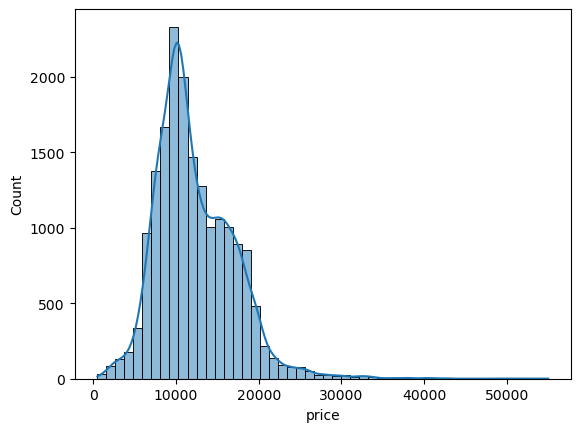

In [5]:
# EDA
sns.histplot(df['price'],bins=50,kde=True)

<Axes: >

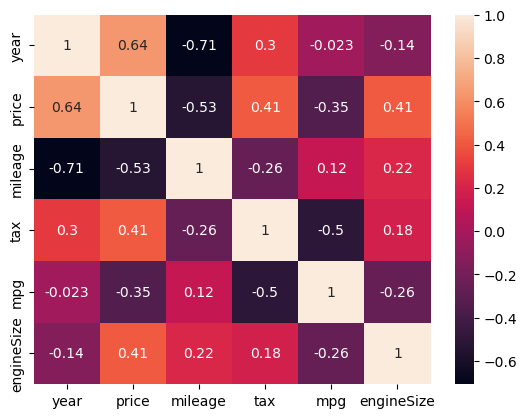

In [6]:
sns.heatmap( df.corr(numeric_only=True),annot=True)
# \(0.0\) to \(0.2\): Very weak / No relationship
# \(0.2\) to \(0.4\): Weak
# \(0.4\) to \(0.6\): Moderate
# \(0.6\) to \(0.8\): Strong
# (0.8\) to \(1.0\): Very strong 

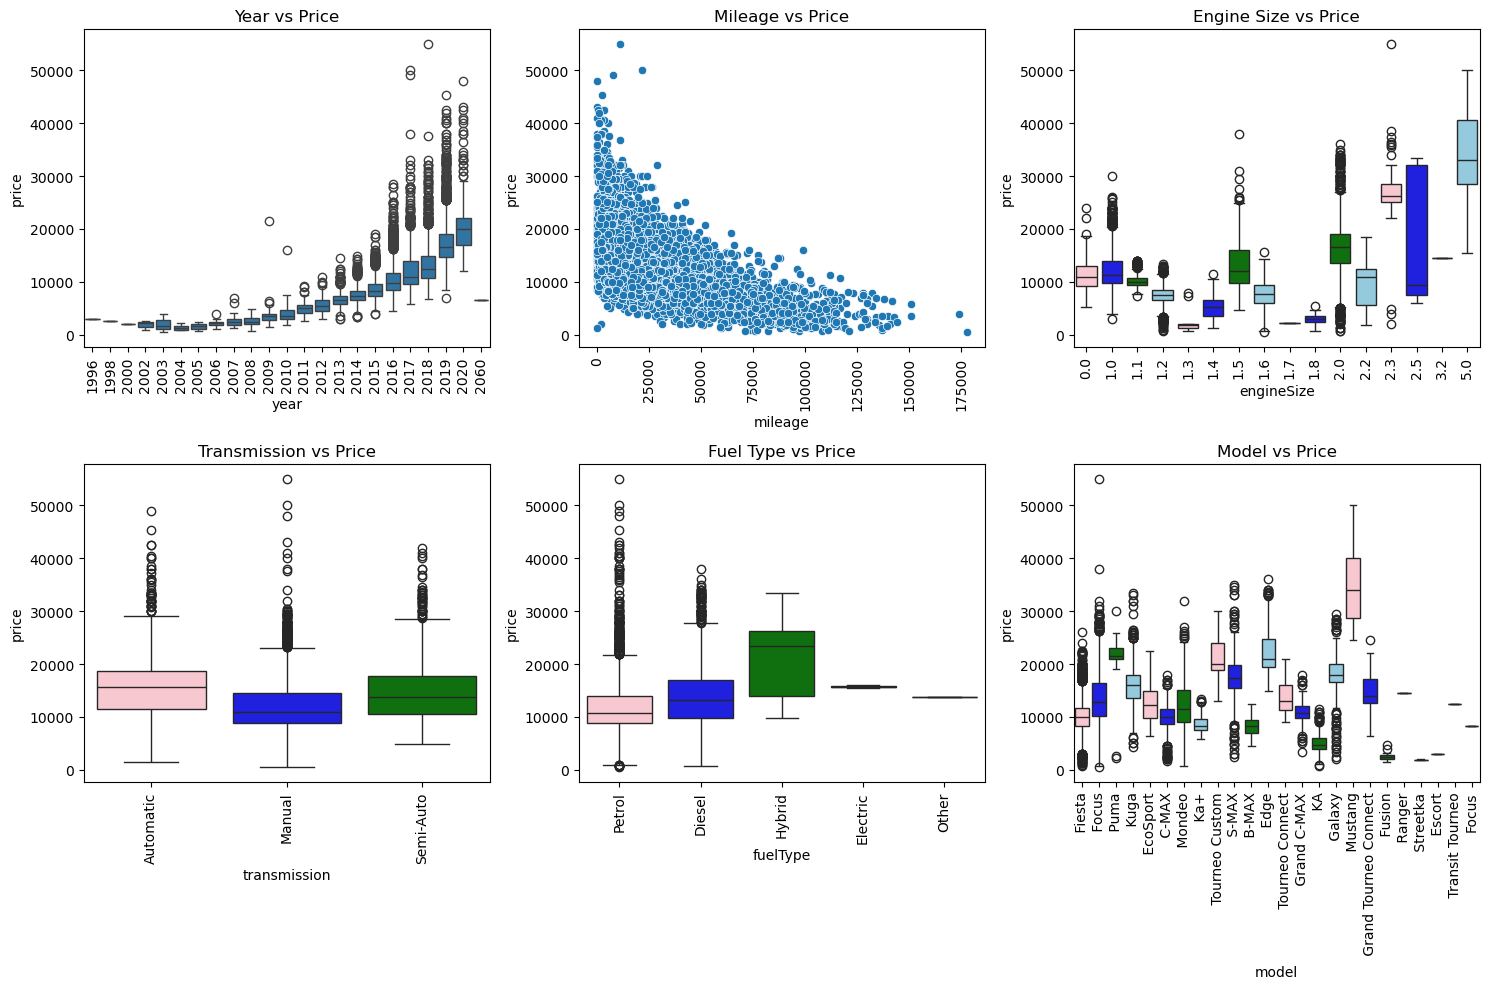

In [7]:
# sns.boxplot(x=df['year'],y=df['price'])
# plt.subplot(2,2,7)
# plt.figure(2,4)
# sns.scatterplot(x=df['mileage'],y=df['price'])
# sns.boxplot(x=df['engineSize'],y=df['price'],palette=['pink', 'blue','green','skyblue'])
# sns.boxplot(x=df['transmission'],y=df['price'],palette=['pink', 'blue','green','skyblue'])
# sns.boxplot(x=df['fuelType'],y=df['price'],palette=['pink', 'blue','green','skyblue'])
# plt.xticks(rotation =90)

# Create a figure with appropriate size
plt.figure(figsize=(15, 10))

# First subplot - boxplot of year vs price
plt.subplot(2, 3, 1)  # Changed to 2x3 grid, position 1
sns.boxplot(x=df['year'], y=df['price'])
plt.title('Year vs Price')
plt.xticks(rotation=90)

# Second subplot - scatter plot of mileage vs price
plt.subplot(2, 3, 2)  # Position 2
sns.scatterplot(x=df['mileage'], y=df['price'])
plt.title('Mileage vs Price')
plt.xticks(rotation=90)

# Third subplot - boxplot of engineSize vs price
plt.subplot(2, 3, 3)  # Position 3
sns.boxplot(x=df['engineSize'], y=df['price'], palette=['pink', 'blue', 'green', 'skyblue'])
plt.title('Engine Size vs Price')
plt.xticks(rotation=90)

# Fourth subplot - boxplot of transmission vs price
plt.subplot(2, 3, 4)  # Position 4
sns.boxplot(x=df['transmission'], y=df['price'], palette=['pink', 'blue', 'green', 'skyblue'])
plt.title('Transmission vs Price')
plt.xticks(rotation=90)

# Fifth subplot - boxplot of fuelType vs price
plt.subplot(2, 3, 5)  # Position 5
sns.boxplot(x=df['fuelType'], y=df['price'], palette=['pink', 'blue', 'green', 'skyblue'])
plt.title('Fuel Type vs Price')
plt.xticks(rotation=90)

# Fifth subplot - boxplot of model vs price
plt.subplot(2, 3, 6)  # Position 5
sns.boxplot(x=df['model'],y=df['price'],palette=['pink', 'blue','green','skyblue'])
plt.title('Model vs Price')
plt.xticks(rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()

In [16]:
x = df.drop(columns=['price'])
y = df['price']

In [17]:
x 

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [18]:
# change categorical and all noninteger in numeric value
x_One_encoded = pd.get_dummies(x,columns=['model','transmission','fuelType'])
x_One_encoded = x_One_encoded.astype(int)
x_One_encoded

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,model_ Focus,model_ Fusion,model_ Galaxy,model_ Grand C-MAX,model_ Grand Tourneo Connect,model_ KA,model_ Ka+,model_ Kuga,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
17962,2014,40700,30,57,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1


In [19]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
columns = ['model','transmission','fuelType'] 
xlabel = x
for i in columns:
    xlabel[i]= encode.fit_transform(xlabel[i])

In [20]:
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [50]:
# standard scaler
from sklearn.preprocessing import StandardScaler
numerical_cols=['year'	,'mileage'	,'tax'	,'mpg',	'engineSize']
scaler = StandardScaler()

x_One_encoded[numerical_cols]=scaler.fit_transform(x_One_encoded[numerical_cols])
x_One_encoded

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,model_ Focus,model_ Fusion,model_ Galaxy,model_ Grand C-MAX,model_ Grand Tourneo Connect,model_ KA,model_ Ka+,model_ Kuga,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1


In [23]:
xlabel.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [25]:
xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']]=scaler.fit_transform(xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])
xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [26]:
# creating models using(one_encode and x_label)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [28]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(x_One_encoded, y, test_size=0.33, random_state=42)
model  = LinearRegression()
model.fit(X_train ,y_train)

LinearRegression()

In [31]:
y_pred= model.predict(X_test)
y_pred

array([ 6888.75487917,  9328.62297666,  9420.53085767, ...,
       19099.96373064,  4948.44438264, 10424.59544226])

In [32]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [36]:
r2 = r2_score(y_test,y_pred)
r2

0.8401880779365886

In [39]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2 = 1-((1-r2) *(n-1))/(n-p-1)
print("Adjusted R score" ,adjusted_r2)

Adjusted R score 0.8391843364467997


In [41]:
# trai test model using xlabel
X_train, X_test, y_train, y_test = train_test_split(xlabel, y, test_size=0.33, random_state=42)
model2  = LinearRegression()
model2.fit(X_train ,y_train)

LinearRegression()

In [42]:
y_pred= model2.predict(X_test)
y_pred

array([ 6157.52473246,  9286.53653694,  9519.82817502, ...,
       19580.21385231,  7384.33202962,  9960.74790235])

In [43]:
y_test # there is so much difference now

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [44]:
r2 = r2_score(y_test,y_pred)
r2

0.731021555739114